# No-arbitrage : pourquoi deux actifs identiques doivent avoir le même prix

**Vidéos qui s'appuieront sur celle-ci plus tard :** FX Spot vs Forward, Futures vs Forwards, Discounting, et plus généralement toute vidéo de pricing (forwards, swaps, options), le no-arbitrage est l'hypothèse qui génère leurs formules.


## 1. Question

**Problème central :**

> Deux façons différentes d'obtenir exactement le même flux futur doivent coûter exactement le même prix aujourd'hui. Si ce n'est pas le cas, quelqu'un peut gagner de l'argent sans aucun risque et ce n'est pas une astuce comptable, c'est un vrai flux d'argent. Pourquoi ce principe, presque trivial en apparence, est-il la brique qui construit toutes les formules de pricing de la finance de marché ?

**Pourquoi ça compte :** avant de voir une seule formule de pricing (forward, swap, option), il faut comprendre *pourquoi* ces formules existent. Elles ne sont pas inventées, elles sont la conséquence directe du no-arbitrage. Une fois ce principe acquis, les prochaines vidéos n'auront plus qu'à l'appliquer à des cas concrets.

## 2. Intuition

Imaginez deux magasins qui vendent exactement le même produit, dans la même quantité, livré au même moment. Si l'un le vend 10% moins cher que l'autre, tout le monde a intérêt à l'acheter chez le premier et, si possible, à le revendre chez le second. Cette activité, acheter là où c'est moins cher, revendre là où c'est plus cher s'appelle l'arbitrage, et elle fait mécaniquement converger les deux prix : la demande fait monter le prix du premier magasin, l'offre fait baisser celui du second, jusqu'à ce que l'écart disparaisse.

En finance de marché, le "produit" n'est pas un bien physique, c'est un **flux d'argent futur**. Deux stratégies qui produisent exactement le même flux futur, avec exactement le même risque, doivent coûter le même prix aujourd'hui. Si ce n'est pas le cas, un arbitrageur peut vendre la stratégie chère, acheter la stratégie identique moins chère, encaisser la différence tout de suite, et n'avoir plus rien à faire ensuite les deux flux futurs s'annulent exactement.

C'est ce principe, et rien d'autre, qui va nous permettre de construire le prix d'un contrat forward sans avoir besoin de connaître la direction future du marché.

## 3. Hypothèses

1. **On peut emprunter et prêter au même taux sans risque** $r$ (pas de spread entre taux emprunteur et taux prêteur).
2. **Aucun coût de transaction** et aucune contrainte de liquidité : on peut acheter, vendre, emprunter et prêter n'importe quelle quantité instantanément.
3. **Les trois cotations de change (section 5.3) sont observées au même instant** pas de délai entre les trois prix.
4. **Pas de risque de contrepartie** : chaque engagement contractuel (forward, prêt, emprunt) sera honoré avec certitude à maturité.

## 4. Notation

| Symbole | Signification | Unité / nature |
|---|---|---|
| $S_0$ | prix spot aujourd'hui (devise domestique par unité de devise étrangère) | prix |
| $F_0$ | prix forward (livraison en $T$) | prix |
| $r$ | taux sans risque domestique (continu) | % annualisé |
| $r_f$ | taux sans risque étranger (continu) | % annualisé |
| $T$ | maturité | années |

*Convention utilisée (identique à Hull, §5.10) : $S_0$ est le prix en devise domestique d'une unité de devise étrangère — par exemple $S_0 = 1{,}08$ si 1 EUR (étranger) vaut 1,08 USD (domestique), conforme à l'ordre de grandeur réel du taux de change EUR/USD.*

**Attention à un piège de convention, important pour la section 5.3 :** un ticker de marché comme `EURUSD` suit toujours la règle *base/cote* — `EURUSD` = nombre d'USD pour 1 EUR (EUR = devise de base, USD = devise cotée). Ce n'est pas la même chose que "la devise domestique de l'investisseur" : pour un investisseur basé en zone euro regardant `EURUSD`, c'est l'USD qui est sa devise étrangère, donc son $S_0$ (domestique par étranger) est $1/\text{EURUSD}$, pas `EURUSD` directement. Ici, pour que $S_0$ coïncide avec le ticker affiché, on se place du point de vue d'un investisseur domestique-USD regardant l'EUR (devise étrangère) — exactement la convention retenue ci-dessus.

## 5. Mathématiques

**5.1 — Le principe général (loi du prix unique).** Si deux portefeuilles $A$ et $B$ produisent exactement le même flux à la date $T$, quel que soit l'état du monde à cette date, alors en l'absence d'arbitrage :

$$\text{Prix}(A)_0 = \text{Prix}(B)_0$$

**Preuve par l'absurde.** Supposons $\text{Prix}(A)_0 > \text{Prix}(B)_0$. Un arbitrageur peut alors : vendre $A$ (encaisser $\text{Prix}(A)_0$), acheter $B$ (payer $\text{Prix}(B)_0$), encaisser la différence $\text{Prix}(A)_0 - \text{Prix}(B)_0 > 0$ aujourd'hui. À la date $T$, le flux reçu de $B$ est exactement égal au flux à payer sur $A$ (puisque les deux produisent le même flux) — l'opération se dénoue à zéro. Le profit encaissé en $0$ est donc un gain certain, sans mise de fonds ni risque. C'est précisément la définition d'un arbitrage, qui ne peut pas persister sur un marché qui fonctionne : la vente de $A$ fait baisser son prix, l'achat de $B$ fait monter le sien, jusqu'à égalité.

**5.2 — Application 1 : le forward de change par parité des taux d'intérêt couverte.** Il existe deux façons de transformer 1 unité de devise étrangère en devise domestique à la date $T$ :

- **Chemin 1 :** placer la devise étrangère au taux $r_f$, puis vendre le produit à terme au prix forward $F_0$ → donne $e^{r_f T} F_0$ en devise domestique.
- **Chemin 2 :** convertir immédiatement au spot $S_0$, puis placer en devise domestique au taux $r$ → donne $S_0 e^{rT}$ en devise domestique.

Ces deux chemins produisent exactement le même flux futur (de la devise domestique certaine à la date $T$), donc par le principe 5.1 ils doivent avoir la même valeur :

$$e^{r_f T} F_0 = S_0 e^{rT} \quad\Longrightarrow\quad F_0 = S_0 e^{(r-r_f)T}$$

*(Hull, 8e éd., §5.10, équation 5.9 — parité des taux d'intérêt couverte / "covered interest rate parity".)*

**5.3 — Application 2 : la cohérence triangulaire entre trois devises.** On utilise ici directement les tickers de marché réels. `EURUSD` (USD pour 1 EUR) et `GBPUSD` (USD pour 1 GBP) permettent de reconstituer `EURGBP` (GBP pour 1 EUR) sans passer par une cotation directe EUR/GBP — il suffit de passer par l'USD comme devise pivot :

$$\text{EURGBP}^{\text{implicite}} = \frac{\text{EURUSD}}{\text{GBPUSD}}$$

*(Vérification dimensionnelle : EURUSD est en USD/EUR, GBPUSD en USD/GBP, leur rapport est donc en GBP/EUR — exactement l'unité du ticker `EURGBP`.)*

Si le `EURGBP` coté directement sur le marché diverge de cette valeur implicite, les trois cotations ne sont pas mutuellement cohérentes, et un chemin (acheter la devise via la synthèse, revendre au prix direct, ou l'inverse) génère un profit sans risque — l'arbitrage triangulaire.

In [3]:
# --- Imports ---
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12

## 6. Implémentation

On code d'abord le prix forward théorique, puis un petit détecteur d'arbitrage qui construit automatiquement le bon portefeuille selon le sens de l'écart.


In [4]:
def forward_theorique(S0, r_dom, r_for, T):
    """Prix forward FX par non-arbitrage (Hull 5.9) : F0 = S0 * exp((r_dom - r_for) * T)."""
    return S0 * np.exp((r_dom - r_for) * T)


def arbitrage_forward_fx(S0, r_dom, r_for, T, F_marche, notional_etranger=1000):
    """Construit le portefeuille d'arbitrage adapté au sens de l'écart entre F_marche et F_theo,
    et renvoie le profit sans risque (en devise domestique).
    Convention : S0, F en devise domestique par unité de devise étrangère.
    """
    F_theo = forward_theorique(S0, r_dom, r_for, T)

    if F_marche < F_theo:
        sens = "forward sous-évalué -> emprunter devise étrangère, placer en domestique, racheter à terme"
        dette_etrangere = notional_etranger * np.exp(r_for * T)
        gain_domestique = notional_etranger * S0 * np.exp(r_dom * T)
        cout_rachat = dette_etrangere * F_marche
        profit = gain_domestique - cout_rachat
    elif F_marche > F_theo:
        sens = "forward sur-évalué -> emprunter devise domestique, placer en étrangère, vendre à terme"
        notional_dom = notional_etranger * S0  # équivalent domestique du notionnel
        etranger_obtenu = notional_dom / S0
        etranger_place = etranger_obtenu * np.exp(r_for * T)
        gain_vente_forward = etranger_place * F_marche
        dette_domestique = notional_dom * np.exp(r_dom * T)
        profit = gain_vente_forward - dette_domestique
    else:
        sens = "aucun écart -> pas d'arbitrage"
        profit = 0.0

    return F_theo, profit, sens


def eurgbp_implicite(EURUSD, GBPUSD):
    """EURGBP implicite (GBP pour 1 EUR), reconstruit via l'USD comme devise pivot.
    Vérification dimensionnelle : (USD/EUR) / (USD/GBP) = GBP/EUR = unité du ticker EURGBP.
    """
    return EURUSD / GBPUSD


def profit_arbitrage_triangulaire(EURUSD, GBPUSD, EURGBP_cote, notional_eur=1_000_000):
    """Profit (en EUR) d'une boucle d'arbitrage à 3 devises, dans le sens qui exploite
    l'écart entre EURGBP coté directement et EURGBP implicite (reconstruit via USD).
    """
    implicite = eurgbp_implicite(EURUSD, GBPUSD)
    if EURGBP_cote > implicite:
        # 1 EUR donne plus de GBP en direct qu'en synthèse -> GBP moins cher à l'achat direct
        # Acheter GBP directement avec EUR, revendre ce GBP via la synthèse (GBP -> USD -> EUR)
        gbp = notional_eur * EURGBP_cote
        usd = gbp * GBPUSD
        eur_final = usd / EURUSD
    elif EURGBP_cote < implicite:
        # 1 EUR donne moins de GBP en direct -> GBP plus cher à l'achat direct
        # Acheter GBP via la synthèse (EUR -> USD -> GBP), revendre au prix direct
        usd = notional_eur * EURUSD
        gbp = usd / GBPUSD
        eur_final = gbp / EURGBP_cote
    else:
        eur_final = notional_eur
    return eur_final - notional_eur, implicite

In [ ]:
# Vérifions que ça donne des nombres qui ont du sens, avant toute chose.

S0, r_dom, r_for, T = 1.0800, 0.035, 0.050, 1.0
F_theo = forward_theorique(S0, r_dom, r_for, T)
print(f"Forward théorique (non-arbitrage) : {F_theo:.4f}")

F_theo_chk, profit_sous, sens_sous = arbitrage_forward_fx(S0, r_dom, r_for, T, F_marche=1.0600)
print(f"Forward coté 1.0600 (sous-évalué) -> {sens_sous}")
print(f"Profit sans risque : {profit_sous:.2f} (devise domestique, pour 1000 unités étrangères empruntées)")

F_theo_chk, profit_sur, sens_sur = arbitrage_forward_fx(S0, r_dom, r_for, T, F_marche=1.0700)
print(f"Forward coté 1.0700 (sur-évalué) -> {sens_sur}")
print(f"Profit sans risque : {profit_sur:.2f}")

Forward théorique (non-arbitrage) : 1.0639
Forward coté 1.0600 (sous-évalué) -> forward sous-évalué -> emprunter devise étrangère, placer en domestique, racheter à terme
Profit sans risque : 4.12 (devise domestique, pour 1000 unités étrangères empruntées)
Forward coté 1.0700 (sur-évalué) -> forward sur-évalué -> emprunter devise domestique, placer en étrangère, vendre à terme
Profit sans risque : 6.39


## 7. Visualisation

**Question posée par ce graphique :** quelle est la relation entre l'écart de prix (forward coté vs forward théorique) et le profit d'arbitrage qu'il génère ?

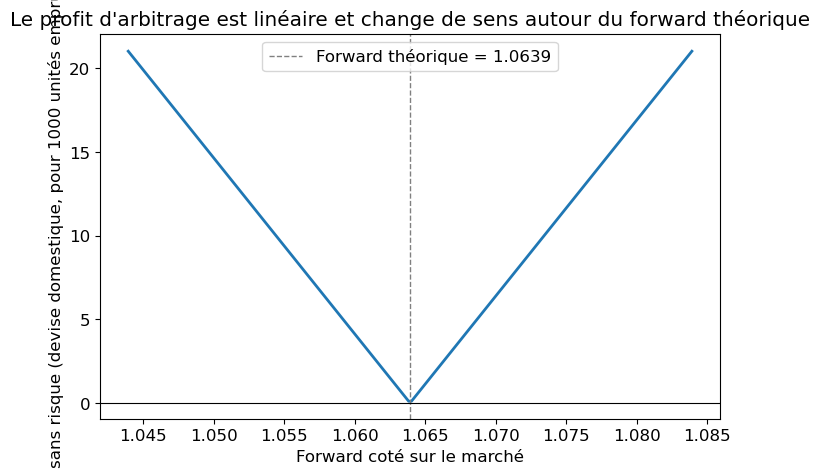

In [ ]:
# profit d'arbitrage en fonction de l'écart au forward théorique
F_marche_range = np.linspace(F_theo - 0.02, F_theo + 0.02, 200)
profits = []
for Fm in F_marche_range:
    _, p, _ = arbitrage_forward_fx(S0, r_dom, r_for, T, F_marche=Fm)
    profits.append(p)

fig, ax = plt.subplots()
ax.plot(F_marche_range, profits, color="#1f77b4", linewidth=2)
ax.axvline(F_theo, color="gray", linestyle="--", linewidth=1, label=f"Forward théorique = {F_theo:.4f}")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Le profit d'arbitrage est linéaire et change de sens autour du forward théorique")
ax.set_xlabel("Forward coté sur le marché")
ax.set_ylabel("Profit sans risque (devise domestique, pour 1000 unités empruntées)")
ax.legend()
plt.show()

## 8. Expériences

Deux variantes déjà calculées : (1) effet de la taille du notionnel sur le profit — le profit est strictement proportionnel, ce qui explique pourquoi les arbitrageurs opèrent avec des montants énormes même sur des écarts minuscules ; (2) l'arbitrage triangulaire avec un mispricing réaliste de 0,3%.

In [7]:
# Variante 1 : effet du notionnel sur le profit d'arbitrage (forward sous-évalué de 1.0639 -> 1.0600)
notionnels = [1_000, 10_000, 1_000_000, 100_000_000]
print("Notionnel emprunté (devise étrangère) -> Profit sans risque (devise domestique)")
for n in notionnels:
    _, p, _ = arbitrage_forward_fx(S0, r_dom, r_for, T, F_marche=1.0600, notional_etranger=n)
    print(f"{n:>15,} -> {p:>15,.2f}   (profit / notionnel = {p/n:.4%})")

Notionnel emprunté (devise étrangère) -> Profit sans risque (devise domestique)
          1,000 ->            4.12   (profit / notionnel = 0.4122%)
         10,000 ->           41.22   (profit / notionnel = 0.4122%)
      1,000,000 ->        4,121.92   (profit / notionnel = 0.4122%)
    100,000,000 ->      412,192.33   (profit / notionnel = 0.4122%)


In [6]:
# Variante 2 : arbitrage triangulaire avec mispricing réaliste de 0.3%, tickers réels
EURUSD = 1.0800
GBPUSD = 1.2600
implicite = eurgbp_implicite(EURUSD, GBPUSD)
EURGBP_cote = implicite * 1.003   # +0.3% d'écart

profit_tri, implicite_chk = profit_arbitrage_triangulaire(EURUSD, GBPUSD, EURGBP_cote)
print(f"EURGBP implicite (via USD) : {implicite_chk:.6f}")
print(f"EURGBP coté directement    : {EURGBP_cote:.6f}  (écart = {(EURGBP_cote/implicite_chk - 1):.3%})")
print(f"Profit sur une boucle de 1 000 000 EUR : {profit_tri:,.2f} EUR  (soit {profit_tri/1_000_000:.3%})")

# sanity check : sans mispricing, la boucle doit redonner exactement le capital de départ
profit_nul, _ = profit_arbitrage_triangulaire(EURUSD, GBPUSD, implicite_chk)
print(f"\nSanity check (sans mispricing) : profit = {profit_nul:.10f} -> doit être 0")

EURGBP implicite (via USD) : 0.857143
EURGBP coté directement    : 0.859714  (écart = 0.300%)
Profit sur une boucle de 1 000 000 EUR : 3,000.00 EUR  (soit 0.300%)

Sanity check (sans mispricing) : profit = 0.0000000000 -> doit être 0


## 9. Résultats

- Le profit d'arbitrage sur le forward FX est **linéaire** en fonction de l'écart entre le forward coté et le forward théorique, et **change de sens** exactement au point où les deux coïncident — ce point est unique et ne dépend d'aucune anticipation sur la direction future du marché.
- Le profit est **strictement proportionnel au notionnel** : un écart minuscule devient un profit significatif à condition de l'exploiter avec un montant suffisant.
- La cohérence triangulaire se vérifie exactement : sans mispricing, la boucle à 3 devises redonne le capital de départ au centime près ; avec un mispricing de 0,3%, le profit de la boucle est de 0,3% exactement — la taille du profit est directement lisible dans la taille de l'incohérence.

## 10. Interprétation financière

**Pour un trader FX ou un desk d'arbitrage :** ces écarts (forward mal coté, cross rates incohérents) existent réellement, mais de façon extrêmement fugace — quelques millisecondes sur les marchés électroniques liquides, parce que de nombreux acteurs équipés d'infrastructures à très faible latence les détectent et les exploitent automatiquement. C'est précisément cette activité d'arbitrage qui **maintient** les prix cohérents en permanence : le no-arbitrage n'est pas une hypothèse qu'on impose de l'extérieur, c'est une conséquence observée du comportement des arbitrageurs eux-mêmes.

**Pour un structureur ou un quant :** c'est ce principe, et uniquement lui, qui permet de pricer un forward sans avoir besoin d'un modèle de prévision du marché. Le prix forward n'est pas "ce qu'on pense que le marché va faire" — c'est le prix qui élimine toute possibilité d'arbitrage entre deux chemins équivalents. Cette distinction (prix d'arbitrage vs anticipation) sera reprise telle quelle dans toutes les vidéos de pricing à venir.

**Pour un risk manager :** le fait que ce profit soit strictement proportionnel au notionnel (section 8) explique pourquoi les limites de position et les contrôles de risque sur les desks d'arbitrage portent autant sur la taille des opérations que sur leur nature — une stratégie "sans risque de marché" n'est pas sans risque opérationnel ou de contrepartie à grande échelle.

## 11. Limites

1. **Taux d'emprunt = taux de prêt** → en réalité, un trader emprunte à un taux plus élevé que celui auquel il prête (bid-offer sur les taux), ce qui réduit ou élimine le profit d'arbitrage apparent pour de petits écarts.
2. **Aucun coût de transaction** → les frais de change, de courtage et les marges bid-ask sur chaque opération consomment une partie du profit théorique.
3. **Cotations simultanées** → en pratique, il existe une latence entre l'observation des trois prix et l'exécution des trois ordres ; un mouvement de marché pendant ce délai peut transformer un "arbitrage" apparent en position risquée.
4. **Pas de risque de contrepartie** → un forward est un engagement bilatéral OTC ; si la contrepartie fait défaut avant la maturité, le flux promis n'est pas garanti.

**Pourquoi le modèle reste utile malgré ces limites :** même imparfait, le no-arbitrage reste l'hypothèse la plus proche de l'observation empirique sur les marchés liquides et électroniques — les écarts mesurés y sont systématiquement petits et de courte durée, ce qui valide le principe même s'il n'est jamais exactement vérifié à chaque instant.

## 12. Conclusion

**Idée essentielle à retenir :**
> Un prix de marché n'a pas besoin d'un modèle de prévision pour être déterminé — il suffit qu'il élimine toute possibilité de gagner de l'argent sans risque face à une stratégie équivalente.

**Lien vers la suite :** ce principe est exactement celui qu'on va réutiliser pour comprendre en détail la mécanique d'une transaction de change spot vs forward, puis la différence entre futures et forwards.

## À vous de jouer

Ce notebook est fait pour être modifié, pas seulement lu :

- Changez les taux `r_dom` et `r_for` section 6 — que se passe-t-il sur le forward théorique quand l'écart de taux s'inverse (devise domestique moins rémunérée que l'étrangère) ?
- Dans la fonction `arbitrage_forward_fx`, essayez un `F_marche` très proche de `F_theo` — vérifiez que le profit devient proportionnellement négligeable à notionnel constant (c'est pour ça qu'on a besoin de gros notionnels, section 8).
- Ajoutez une quatrième devise et testez une boucle d'arbitrage à 4 devises — la condition de cohérence se généralise-t-elle facilement ?

Code source complet et notebooks des autres vidéos : [github.com/dmorabi](https://github.com/dmorabi)
Repo de cette vidéo : `03-no-arbitrage/notebook.ipynb`

---
## Sources

- J. Hull, *Options, Futures and Other Derivatives*, 8e éd., chapitre 5, §5.10, équation (5.9) — parité des taux d'intérêt couverte.
- Document interne du projet : `Futures-Forwards_merged_watermark.pdf`.
- R. Susmel (University of Houston, Bauer College of Business), *Chapter 7 — Arbitrage in FX Markets: Triangular & Covered (IRP) Arbitrage* (support de cours académique, utilisé pour cross-vérifier la convention de l'arbitrage triangulaire).

*Les taux d'intérêt et de change utilisés dans ce notebook sont des valeurs construites pour la pédagogie, pas des cotations de marché réelles au jour du tournage — précisé à l'écran.*